In [1]:
import pandas as pd
import numpy as np
from numpy import transpose as T
from numpy import genfromtxt as gftxt
import glob
import os
import cartopy
import cartopy.crs as ccrs
import matplotlib
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import rasterio
from rasterio.plot import show
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.mask import mask
import geopandas as gpd
from scipy.optimize import curve_fit
from scipy.ndimage import distance_transform_edt
from scipy import interpolate
from netCDF4 import Dataset
import scipy
from scipy import stats
from scipy import ndimage
from pyproj import CRS, Transformer
from datetime import datetime,timedelta
import regionmask
from shapely.prepared import prep
from shapely.geometry import Point
from shapely.geometry import box
from brokenaxes import brokenaxes
import sys
from pathlib import Path


In [2]:
sys.path.append(str(Path.cwd().parents[1]))
from utils.grid_map_functions import(land_masking, defining_grids)

map_projection = ccrs.NorthPolarStereo()

x_grid_edge_25,y_grid_edge_25,new_x_edge_25,new_y_edge_25 = defining_grids(map_projection,[-180, 180, 90, 65],25000,'edge')
x_grid_centre_25,y_grid_centre_25,new_x_centre_25,new_y_centre_25 = defining_grids(map_projection,[-180, 180, 90, 65],25000,'centre')
land_mask_25 = land_masking(new_x_centre_25,new_y_centre_25,map_projection)

transformer = Transformer.from_crs(map_projection, "EPSG:4326", always_xy=True)
lon0, lat0 = transformer.transform(new_x_centre_25.ravel(), new_y_centre_25.ravel())
lon1 = lon0.reshape(new_x_centre_25.shape)
lat1 = lat0.reshape(new_y_centre_25.shape)

from utils.stats_functions import(absdiff,corr,rmsd)

base_dir = ('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/')

In [3]:
def masking_altimeters(input_directory,date,ls8_boundary,buffer):
    ls8_boundary_crs = ls8_boundary.crs
    if ls8_boundary_crs != 4326:
        print('! Not correct projection !') # verify the raster crs is in 4326
        print()
        print(ls8_boundary_crs)
        return
    if ls8_boundary_crs == 4326:
        print(ls8_boundary_crs)
    area_mask = ls8_area_masking(lon1, lat1, ls8_boundary, buffer=buffer)

    is2_leads = np.load(f'{input_directory}LS8/TenDay_Densities/IS2/{date}_LS8TenDay_IS2_Lead_Density.npy')
    is2_leads_cropped = np.where(area_mask, is2_leads, np.nan)
    
    cs2_leads = np.load(f'{input_directory}LS8/TenDay_Densities/CS2/{date}_LS8TenDay_CS2_Lead_Density.npy')
    cs2_leads_cropped = np.where(area_mask, cs2_leads, np.nan)
  
    s3_leads = np.load(f'{input_directory}LS8/TenDay_Densities/S3/{date}_LS8TenDay_S3_Lead_Density.npy')
    s3_leads_cropped = np.where(area_mask, s3_leads, np.nan)

    leads_stacked = np.stack([is2_leads_cropped,cs2_leads_cropped,s3_leads_cropped],axis=0)
    merged_leads_cropped = np.nanmean(leads_stacked,axis=0)

    return(is2_leads_cropped,cs2_leads_cropped,s3_leads_cropped,merged_leads_cropped)


def ls8_area_masking(lon, lat, shapefile, buffer):
    # Union all geometries
    geom = shapefile.geometry.union_all()

    # Apply buffer if requested
    if buffer != 0:
        geom = geom.buffer(buffer)

    # Prep geometry for fast lookup
    p_geom = prep(geom)

    # Create mask
    mask = np.zeros(lon.shape, dtype=bool)
    for i in range(lon.shape[0]):
        for j in range(lon.shape[1]):
            mask[i, j] = p_geom.contains(Point(lon[i, j], lat[i, j]))

    return mask

In [4]:
base_dir = ('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/')

# 20210327
boundary_20210327 = gpd.read_file(f'{base_dir}LS8/LS8_Img_Data/LS8_Img_Boundaries_Clipped/Clipped_4326_LS8_20210327_175914_038010_Boundary.shp')

is2_20210327,cs2_20210327,s3_20210327,merged_20210327 = masking_altimeters(base_dir,'20210327',boundary_20210327,0.0)

ls8_20210327 = np.load(f'{base_dir}LS8/TenDay_Densities/LS8/20210327_038010_LS8_Lead_Density.npy')

plt_boundary_20210327 = gpd.read_file(f'{base_dir}LS8/LS8_Img_Data/LS8_Img_Boundaries_4326/4326_LS8_20210327_175914_038010_Boundary.shp')
boundary_20210327_reproj = boundary_20210327.to_crs(map_projection)
if boundary_20210327_reproj.crs == map_projection:
    minx_20210327,miny_20210327,maxx_20210327,maxy_20210327 = boundary_20210327_reproj.total_bounds
else:
    print('! Projection mismatch !')

# 20200315
boundary_20200315 = gpd.read_file(f'{base_dir}LS8/LS8_Img_Data/LS8_Img_Boundaries_Clipped/Clipped_4326_LS8_20200315_031420_128007_Boundary.shp')

is2_20200315,cs2_20200315,s3_20200315,merged_20200315 = masking_altimeters(base_dir,'20200315',boundary_20200315,0.0)

ls8_20200315 = np.load(f'{base_dir}LS8/TenDay_Densities/LS8/20200315_128007_LS8_Lead_Density.npy')

plt_boundary_20200315 = gpd.read_file(f'{base_dir}LS8/LS8_Img_Data/LS8_Img_Boundaries_4326/4326_LS8_20200315_031420_128007_Boundary.shp')
boundary_20200315_reproj = boundary_20200315.to_crs(map_projection)
if boundary_20200315_reproj.crs == map_projection:
    minx_20200315,miny_20200315,maxx_20200315,maxy_20200315 = boundary_20200315_reproj.total_bounds
else:
    print('! Projection mismatch !')


# 2022419
boundary_20220419 = gpd.read_file(f'{base_dir}LS8/LS8_Img_Data/LS8_Img_Boundaries_Clipped/Clipped_4326_LS8_20220419_123418_219001_Boundary.shp')

is2_20220419,cs2_20220419,s3_20220419,merged_20220419 = masking_altimeters(base_dir,'20220419',boundary_20220419,0.0)

ls8_20220419 = np.load(f'{base_dir}LS8/TenDay_Densities/LS8/20220419_219001_LS8_Lead_Density.npy')

plt_boundary_20220419 = gpd.read_file(f'{base_dir}LS8/LS8_Img_Data/LS8_Img_Boundaries_4326/4326_LS8_20220419_123418_219001_Boundary.shp')
boundary_20220419_reproj = plt_boundary_20220419.to_crs(map_projection)
if boundary_20220419_reproj.crs == map_projection:
    minx_20220419,miny_20220419,maxx_20220419,maxy_20220419 = boundary_20220419_reproj.total_bounds
else:
    print('! Projection mismatch !')

# 20230417
boundary_20230417 = gpd.read_file(f'{base_dir}LS8/LS8_Img_Data/LS8_Img_Boundaries_Clipped/Clipped_4326_LS8_20230417_072137_168008_Boundary.shp')

is2_20230417,cs2_20230417,s3_20230417,merged_20230417 = masking_altimeters(base_dir,'20230417',boundary_20230417,0.0)

ls8_20230417 = np.load(f'{base_dir}LS8/TenDay_Densities/LS8/20230417_168008_LS8_Lead_Density.npy')

plt_boundary_20230417 = gpd.read_file(f'{base_dir}LS8/LS8_Img_Data/LS8_Img_Boundaries_4326/4326_LS8_20230417_072137_168008_Boundary.shp')
boundary_20230417_reproj = boundary_20230417.to_crs(map_projection)
if boundary_20230417_reproj.crs == map_projection:
    minx_20230417,miny_20230417,maxx_20230417,maxy_20230417 = boundary_20230417_reproj.total_bounds
else:
    print('! Projection mismatch !')


# 20240324
boundary_20240324 = gpd.read_file(f'{base_dir}LS8/LS8_Img_Data/LS8_Img_Boundaries_Clipped/Clipped_4326_LS8_20240324_195345_057003_Boundary.shp')

is2_20240324,cs2_20240324,s3_20240324,merged_20240324 = masking_altimeters(base_dir,'20240324',boundary_20240324,0.0)

ls8_20240324 = np.load(f'{base_dir}LS8/TenDay_Densities/LS8/20240324_057003_LS8_Lead_Density.npy')

plt_boundary_20240324 = gpd.read_file(f'{base_dir}LS8/LS8_Img_Data/LS8_Img_Boundaries_4326/4326_LS8_20240324_195345_057003_Boundary.shp')
boundary_20240324_reproj = boundary_20240324.to_crs(map_projection)
if boundary_20240324_reproj.crs == map_projection:
    minx_20240324,miny_20240324,maxx_20240324,maxy_20240324 = boundary_20240324_reproj.total_bounds
else:
    print('! Projection mismatch !')

EPSG:4326


/var/folders/q1/prwbhm6j6x1gcchb7r0p2kyh0000gn/T/ipykernel_11726/1599825384.py:22: RuntimeWarning: Mean of empty slice
  merged_leads_cropped = np.nanmean(leads_stacked,axis=0)


EPSG:4326


/var/folders/q1/prwbhm6j6x1gcchb7r0p2kyh0000gn/T/ipykernel_11726/1599825384.py:22: RuntimeWarning: Mean of empty slice
  merged_leads_cropped = np.nanmean(leads_stacked,axis=0)


EPSG:4326


/var/folders/q1/prwbhm6j6x1gcchb7r0p2kyh0000gn/T/ipykernel_11726/1599825384.py:22: RuntimeWarning: Mean of empty slice
  merged_leads_cropped = np.nanmean(leads_stacked,axis=0)


EPSG:4326


/var/folders/q1/prwbhm6j6x1gcchb7r0p2kyh0000gn/T/ipykernel_11726/1599825384.py:22: RuntimeWarning: Mean of empty slice
  merged_leads_cropped = np.nanmean(leads_stacked,axis=0)


EPSG:4326


/var/folders/q1/prwbhm6j6x1gcchb7r0p2kyh0000gn/T/ipykernel_11726/1599825384.py:22: RuntimeWarning: Mean of empty slice
  merged_leads_cropped = np.nanmean(leads_stacked,axis=0)


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y

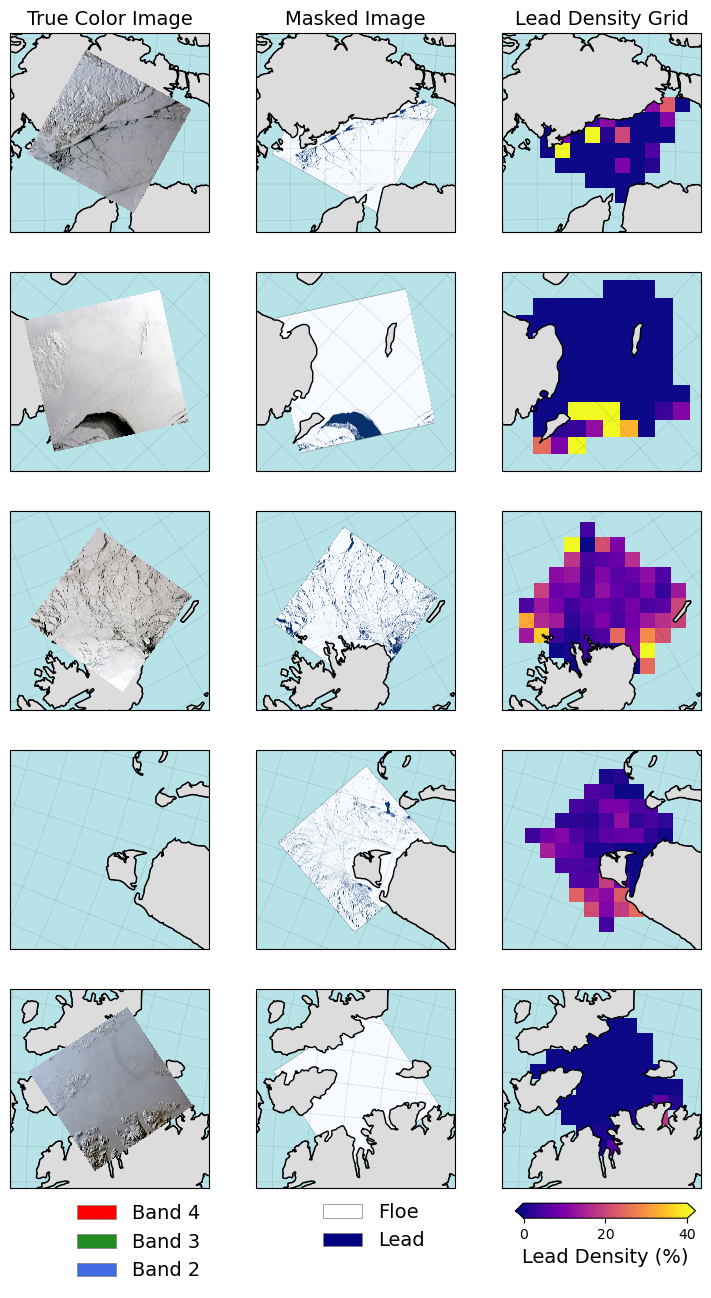

In [5]:
base_dir = ('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/')

floe = mpatches.Patch(facecolor='white', edgecolor='grey',linewidth=0.5,label='Floe')
lead = mpatches.Patch(facecolor='navy', edgecolor='grey',linewidth=0.5,label='Lead')
red_rgb = mpatches.Patch(facecolor='red', edgecolor='grey',linewidth=0.5,label='Band 4')
green_rgb = mpatches.Patch(facecolor='forestgreen', edgecolor='grey',linewidth=0.5,label='Band 3')
blue_rgb = mpatches.Patch(facecolor='royalblue', edgecolor='grey',linewidth=0.5,label='Band 2')


fig, ax = plt.subplots(5, 3,figsize=(9,15),subplot_kw={'projection': map_projection})

for a in ax.flat:
    a.coastlines(linewidth=0.2, zorder=2.5)
    a.gridlines(linewidth=0.3, color='k', alpha=0.5, linestyle=':')
    a.add_feature(cartopy.feature.LAND, facecolor='gainsboro', edgecolor='black', zorder=2)
    a.add_feature(cartopy.feature.OCEAN, facecolor='powderblue', alpha=0.9, edgecolor='black', zorder=0)
    a.set_box_aspect(1) 

ax[0,0].set_title('True Color Image',fontsize=14)
ax[0,1].set_title('Masked Image',fontsize=14)
ax[0,2].set_title('Lead Density Grid',fontsize=14)

lead_kwargs = dict(cmap='plasma',transform=map_projection,vmin=0,vmax=40,zorder=1)

# 20210327
ls8_img = rasterio.open(f'{base_dir}LS8/LS8_Img_Data/20210327/LC08_20210327_175914_038010_TC_Cartopy.tif')
with ls8_img as src:
    rgb = src.read([4,3,2]).astype(float)
    nodata = src.nodata
    if nodata is None:
        nodata = 0 
    rgb[rgb == nodata] = np.nan
for i in range(3):
    band = rgb[i]
    p2, p98 = np.nanpercentile(band, (2, 98))
    rgb[i] = np.clip((band - p2) / (p98 - p2), 0, 1)
show(rgb, ax=ax[0,0], transform=src.transform,zorder=3)
    
ls8_binary = rasterio.open(f'{base_dir}LS8/LS8_Img_Data/20210327/LC08_20210327_175914_038010_18000_Cartopy.tif')
with ls8_binary as src:
   show(src, ax=ax[0,1], transform=src.transform, cmap='Blues_r') 

ls8_grid = ax[0,2].pcolormesh(new_x_edge_25,new_y_edge_25,ls8_20210327,**lead_kwargs)

# 20200315
ls8_img = rasterio.open(f'{base_dir}LS8/LS8_Img_Data/20200315/LC08_20200315_20200822_128007_TC_Cartopy.tif')
with ls8_img as src:
    rgb = src.read([4,3,2]).astype(float)
    nodata = src.nodata
    if nodata is None:
        nodata = 0 
    rgb[rgb == nodata] = np.nan
for i in range(3):
    band = rgb[i]
    p2, p98 = np.nanpercentile(band, (2, 98))
    rgb[i] = np.clip((band - p2) / (p98 - p2), 0, 1)
show(rgb, ax=ax[1,0], transform=src.transform,zorder=3)
    
ls8_binary = rasterio.open(f'{base_dir}LS8/LS8_Img_Data/20200315/LC08_20200315_20200822_128007_11500_Cartopy.tif')
with ls8_binary as src:
   show(src, ax=ax[1,1], transform=src.transform, cmap='Blues_r') 

ls8_grid = ax[1,2].pcolormesh(new_x_edge_25,new_y_edge_25,ls8_20200315,**lead_kwargs)

# 20220419
ls8_img = rasterio.open(f'{base_dir}LS8/LS8_Img_Data/20220419/LC08_20220419_20220427_219001_TC_Cartopy.tif')
with ls8_img as src:
    rgb = src.read([4,3,2]).astype(float)
    nodata = src.nodata
    if nodata is None:
        nodata = 0 
    rgb[rgb == nodata] = np.nan
for i in range(3):
    band = rgb[i]
    p2, p98 = np.nanpercentile(band, (2, 98))
    rgb[i] = np.clip((band - p2) / (p98 - p2), 0, 1)
show(rgb, ax=ax[2,0], transform=src.transform,zorder=3)
    
ls8_binary = rasterio.open(f'{base_dir}LS8/LS8_Img_Data/20220419/LC08_20220419_20220427_219001_15000_Cartopy.tif')
with ls8_binary as src:
   show(src, ax=ax[2,1], transform=src.transform, cmap='Blues_r') 

ls8_grid = ax[2,2].pcolormesh(new_x_edge_25,new_y_edge_25,ls8_20220419,**lead_kwargs)

# 20230417
ls8_img = rasterio.open(f'{base_dir}LS8/LS8_Img_Data/20230417/LC08_20230417_20230428_168008_TC_Cartopy.tif')
with ls8_img as src:
    rgb = src.read([4,3,2]).astype(float)
    nodata = src.nodata
    if nodata is None:
        nodata = 0 
    rgb[rgb == nodata] = np.nan
for i in range(3):
    band = rgb[i]
    p2, p98 = np.nanpercentile(band, (2, 98))
    rgb[i] = np.clip((band - p2) / (p98 - p2), 0, 1)
show(rgb, ax=ax[3,0], transform=src.transform,zorder=3)
    
ls8_binary = rasterio.open(f'{base_dir}LS8/LS8_Img_Data/20230417/LC08_20230417_20230428_168008_20000_Cartopy.tif')
with ls8_binary as src:
   show(src, ax=ax[3,1], transform=src.transform, cmap='Blues_r') 

ls8_grid = ax[3,2].pcolormesh(new_x_edge_25,new_y_edge_25,ls8_20230417,**lead_kwargs)

# 20240324
ls8_img = rasterio.open(f'{base_dir}LS8/LS8_Img_Data/20240324/LC08_20240324_195345_057003_TC_Cartopy.tif')
with ls8_img as src:
    rgb = src.read([4,3,2]).astype(float)
    nodata = src.nodata
    if nodata is None:
        nodata = 0 
    rgb[rgb == nodata] = np.nan
for i in range(3):
    band = rgb[i]
    p2, p98 = np.nanpercentile(band, (2, 98))
    rgb[i] = np.clip((band - p2) / (p98 - p2), 0, 1)
show(rgb, ax=ax[4,0], transform=src.transform,zorder=3)
    
ls8_binary = rasterio.open(f'{base_dir}LS8/LS8_Img_Data/20240324/LC08_20240324_195345_057003_11000_Cartopy.tif')
with ls8_binary as src:
   show(src, ax=ax[4,1], transform=src.transform, cmap='Blues_r') 

ls8_grid = ax[4,2].pcolormesh(new_x_edge_25,new_y_edge_25,ls8_20240324,**lead_kwargs)


for i in range(0,3):
    ax[0,i].set_extent([minx_20210327-25000, maxx_20210327+25000, miny_20210327-25000, maxy_20210327+25000],
             crs=map_projection)
    ax[1,i].set_extent([minx_20200315-25000, maxx_20200315+25000, miny_20200315-25000, maxy_20200315+25000],
                 crs=map_projection)
    ax[2,i].set_extent([minx_20220419-25000, maxx_20220419+25000, miny_20220419-25000, maxy_20220419+25000],
         crs=map_projection)
    ax[3,i].set_extent([minx_20230417-25000, maxx_20230417+25000, miny_20230417-25000, maxy_20230417+25000],
         crs=map_projection)
    ax[4,i].set_extent([minx_20240324-25000, maxx_20240324+25000, miny_20240324-25000, maxy_20240324+25000],
         crs=map_projection)

ax[4,0].legend(handles=[red_rgb, green_rgb,blue_rgb], loc='lower left',bbox_to_anchor=(0.25, -0.55),
              frameon=False,fontsize=14)

ax[4,1].legend(handles=[floe, lead], loc='lower left',bbox_to_anchor=(0.25, -0.4),
              frameon=False,fontsize=14)

cax = fig.add_axes([0.69, 0.09, 0.2, 0.01])  # [left, bottom, width, height]
cb = fig.colorbar(ls8_grid, cax=cax,extend='both',orientation='horizontal')
cb.set_label('Lead Density (%)',fontsize=14)

plt.show()

fig.savefig('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Arctic_Lead_Density/Figures/FigA1.png',dpi=300,bbox_inches="tight")